In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!mkdir -p /content/datasets/pk_lot
!unzip -q -o /content/drive/MyDrive/PKLot.v2-640.yolov11.zip \
    -d /content/datasets/pk_lot


In [ ]:
import yaml

DATA_ROOT = '/content/datasets/pk_lot'
with open(f"{DATA_ROOT}/data.yaml") as f:
    cfg = yaml.safe_load(f)

classes = cfg['names']
print("Classes:", classes)


Classes: ['space-empty', 'space-occupied']


In [ ]:
import os
SPLITS = {
    'train': {'imgs': os.path.join(DATA_ROOT, 'train', 'images'),
              'lbls': os.path.join(DATA_ROOT, 'train', 'labels')},
    'valid':{'imgs': os.path.join(DATA_ROOT, 'valid', 'images'),
             'lbls': os.path.join(DATA_ROOT, 'valid', 'labels')},
    'test' :{'imgs': os.path.join(DATA_ROOT, 'test', 'images'),
             'lbls': os.path.join(DATA_ROOT, 'test', 'labels')},
}

for split, p in SPLITS.items():
    print(f"{split:5}: {len(os.listdir(p['imgs']))} images, {len(os.listdir(p['lbls']))} labels")


train: 8691 images, 8691 labels
valid: 2483 images, 2483 labels
test : 1242 images, 1242 labels


In [ ]:
import glob
from PIL import Image

one = glob.glob(f"{SPLITS['train']['imgs']}/*.*")[0]
w,h = Image.open(one).size
imgsz = max(w, h)
print(f"Using imgsz = {w}×{h}")


Using imgsz = 640×640


In [ ]:
!pip install -q rfdetr==1.1.0 supervision pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.3/266.3 kB 26.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━

In [ ]:
import json, glob, os
from PIL import Image

def convert_yolo_to_coco(split):
    img_dir = SPLITS[split]['imgs']
    lbl_dir = SPLITS[split]['lbls']
    out_json = os.path.join(DATA_ROOT, split, '_annotations.coco.json')

    images, annotations = [], []
    ann_id = 0

    for img_id, img_path in enumerate(sorted(glob.glob(f"{img_dir}/*.*"))):
        fn = os.path.basename(img_path)
        w, h = Image.open(img_path).size

        images.append({
            'id': img_id,
            'file_name': f"images/{fn}",
            'width': w,
            'height': h
        })

        lbl_file = os.path.join(lbl_dir, fn.replace(os.path.splitext(fn)[1], '.txt'))
        if os.path.exists(lbl_file):
            for line in open(lbl_file):
                cls, xc, yc, bw, bh = line.split()
                cls = int(cls)
                xc, yc, bw, bh = map(float, (xc, yc, bw, bh))
                x = (xc - bw/2) * w
                y = (yc - bh/2) * h
                width  = bw * w
                height = bh * h
                annotations.append({
                    'id': ann_id,
                    'image_id': img_id,
                    'category_id': cls,
                    'bbox': [x, y, width, height],
                    'area': width * height,
                    'iscrowd': 0
                })
                ann_id += 1

    categories = [
        {'id': i, 'name': name, 'supercategory': 'none'}
        for i, name in enumerate(classes)
    ]

    coco = {'images': images, 'annotations': annotations, 'categories': categories}
    with open(out_json, 'w') as f:
        json.dump(coco, f)
    print(f"[{split}] {len(images)} images, {ann_id} annotations → {out_json}")

for split in SPLITS:
    convert_yolo_to_coco(split)


[train] 8691 images, 497856 annotations → /content/datasets/pk_lot/train/_annotations.coco.json
[valid] 2483 images, 143316 annotations → /content/datasets/pk_lot/valid/_annotations.coco.json
[test] 1242 images, 70684 annotations → /content/datasets/pk_lot/test/_annotations.coco.json


In [ ]:
import os
from rfdetr import RFDETRBase
import supervision as sv
from tqdm import tqdm
import matplotlib.pyplot as plt
from supervision.metrics import MeanAveragePrecision

RUN_DIR  = '/content/drive/MyDrive/rfdetr_pklot_run'
CKPT_DIR = os.path.join(RUN_DIR, 'checkpoint')
os.makedirs(CKPT_DIR, exist_ok=True)


In [ ]:
model = RFDETRBase()
model.train(
    dataset_dir        = DATA_ROOT,
    epochs             = 3,
    batch_size         = 8,
    grad_accum_steps   = 2,
    lr                 = 1e-4,
    imgsz              = imgsz,
    fp16               = True,
    dataloader_workers = 8
)


rf-detr-base.pth: 100%|██████████| 355M/355M [00:16<00:00, 22.2MiB/s]
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading pretrain weights


reinitializing your detection head with 2 classes.


TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir output' and open http://localhost:6006/ in browser.
Not using distributed mode
git:
  sha: N/A, status: clean, branch: N/A

Namespace(num_classes=2, grad_accum_steps=2, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=8, weight_decay=0.0001, epochs=3, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-base.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[2, 5, 8, 11], freeze_encoder=False, layer_norm=True, rms_norm=False, backbone_lora=False, force_no_pretrain=False, dec_layers=3, dim_feedforward=2048, hidden_dim=256, sa_nheads=8, ca_nheads=16

Epoch: [0]  [  0/543]  eta: 0:48:01  lr: 0.000100  class_error: 36.52  loss: 18.3397 (18.3397)  loss_ce: 0.4656 (0.4656)  loss_bbox: 1.8496 (1.8496)  loss_giou: 2.2175 (2.2175)  loss_ce_0: 0.4403 (0.4403)  loss_bbox_0: 1.9129 (1.9129)  loss_giou_0: 2.2766 (2.2766)  loss_ce_1: 0.4533 (0.4533)  loss_bbox_1: 1.8636 (1.8636)  loss_giou_1: 2.2288 (2.2288)  loss_ce_enc: 0.4444 (0.4444)  loss_bbox_enc: 1.9186 (1.9186)  loss_giou_enc: 2.2683 (2.2683)  loss_ce_unscaled: 0.4656 (0.4656)  class_error_unscaled: 36.5238 (36.5238)  loss_bbox_unscaled: 0.3699 (0.3699)  loss_giou_unscaled: 1.1088 (1.1088)  cardinality_error_unscaled: 144.8750 (144.8750)  loss_ce_0_unscaled: 0.4403 (0.4403)  loss_bbox_0_unscaled: 0.3826 (0.3826)  loss_giou_0_unscaled: 1.1383 (1.1383)  cardinality_error_0_unscaled: 957.7500 (957.7500)  loss_ce_1_unscaled: 0.4533 (0.4533)  loss_bbox_1_unscaled: 0.3727 (0.3727)  loss_giou_1_unscaled: 1.1144 (1.1144)  cardinality_error_1_unscaled: 1387.8750 (1387.8750)  loss_ce_enc_unscale

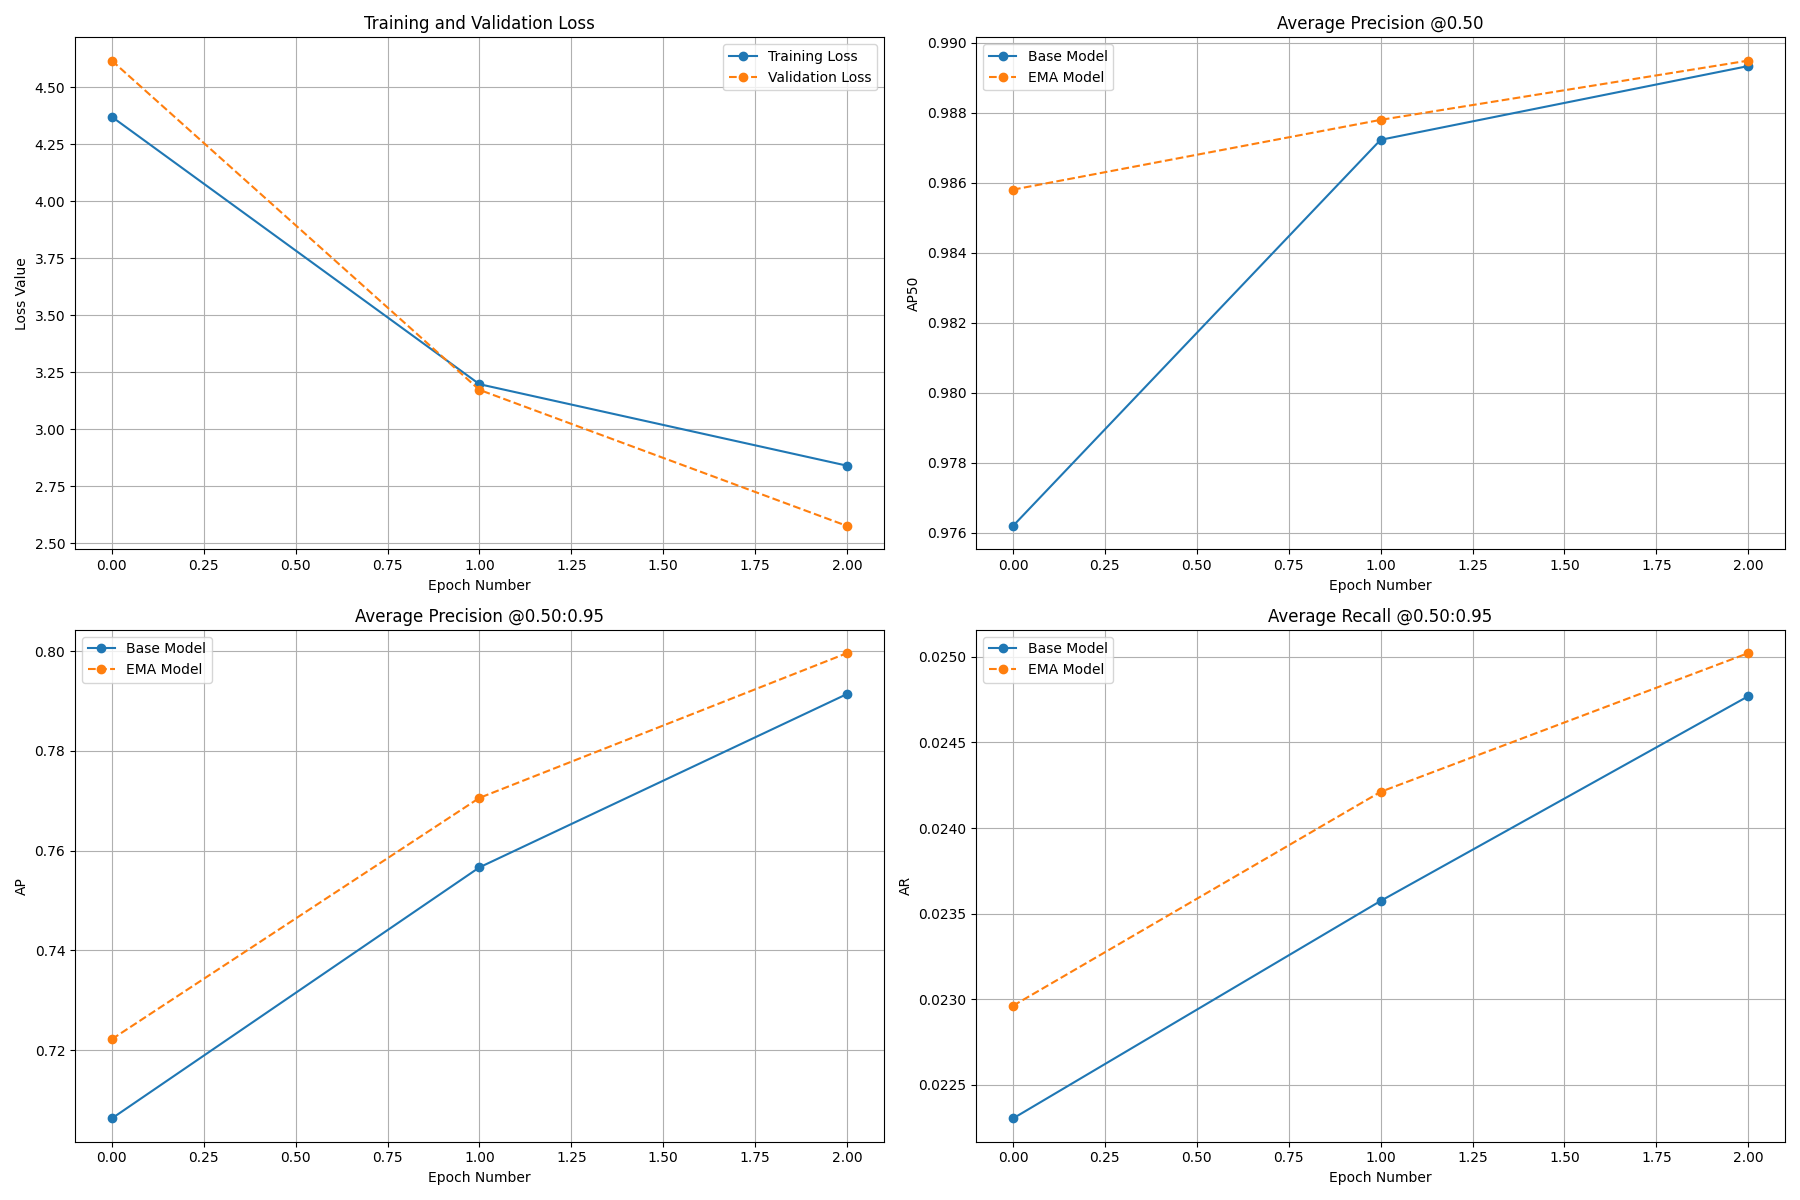

In [ ]:
from PIL import Image

Image.open("/content/output/metrics_plot.png")

In [ ]:
import torch, os, yaml

os.makedirs(CKPT_DIR, exist_ok=True)

torch.save(model, os.path.join(CKPT_DIR, "rf_detr_base_full.pt"))

with open(os.path.join(CKPT_DIR, "training_config.yaml"), "w") as f:
    yaml.safe_dump({
        "imgsz": imgsz,
        "batch_size": 8,
        "epochs": 5,
        "lr": 1e-4,
        "classes": classes
    }, f)

print("checkpoint saved to", CKPT_DIR)


checkpoint saved to /content/drive/MyDrive/rfdetr_pklot_run/checkpoint


In [ ]:
import os
import supervision as sv
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from supervision.metrics import MeanAveragePrecision

DATA_ROOT = '/content/datasets/pk_lot'
RUN_DIR   = '/content/drive/MyDrive/rfdetr_pklot_run'

In [ ]:
eval_model = model

ds = sv.DetectionDataset.from_coco(
    images_directory_path = os.path.join(DATA_ROOT, 'test'),
    annotations_path      = os.path.join(DATA_ROOT, 'test', '_annotations.coco.json'),
)
print("Test classes:", ds.classes)
print("Number of test images:", len(ds))

Test classes: ['space-empty', 'space-occupied']
Number of test images: 1242


In [ ]:
preds, targets = [], []
for img_path, _, ann in tqdm(ds, desc="Inferencing"):
    img  = Image.open(img_path)
    dets = eval_model.predict(img, threshold=0.5)
    preds.append(dets)
    targets.append(ann)

Inferencing: 100%|██████████| 1242/1242 [00:41<00:00, 29.81it/s]


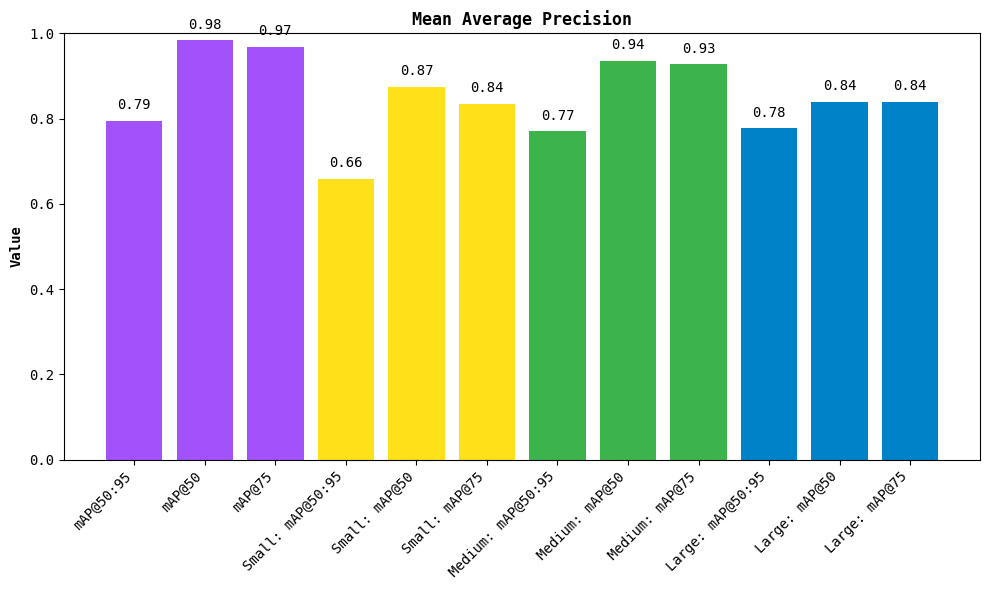

mAP plot → mAP.png


In [ ]:
map_metric = MeanAveragePrecision()
res        = map_metric.update(preds, targets).compute()

res.plot()
plt.gcf().savefig(os.path.join(RUN_DIR,'mAP.png'), bbox_inches='tight')
plt.close()
print("mAP plot → mAP.png")

In [ ]:
cm = sv.ConfusionMatrix.from_detections(
    predictions = preds,
    targets     = targets,
    classes     = ds.classes
)
cm.plot()
plt.gcf().savefig(os.path.join(RUN_DIR,'confusion_matrix.png'), bbox_inches='tight')
plt.close()
print("Confusion matrix → confusion_matrix.png")

Confusion matrix → confusion_matrix.png


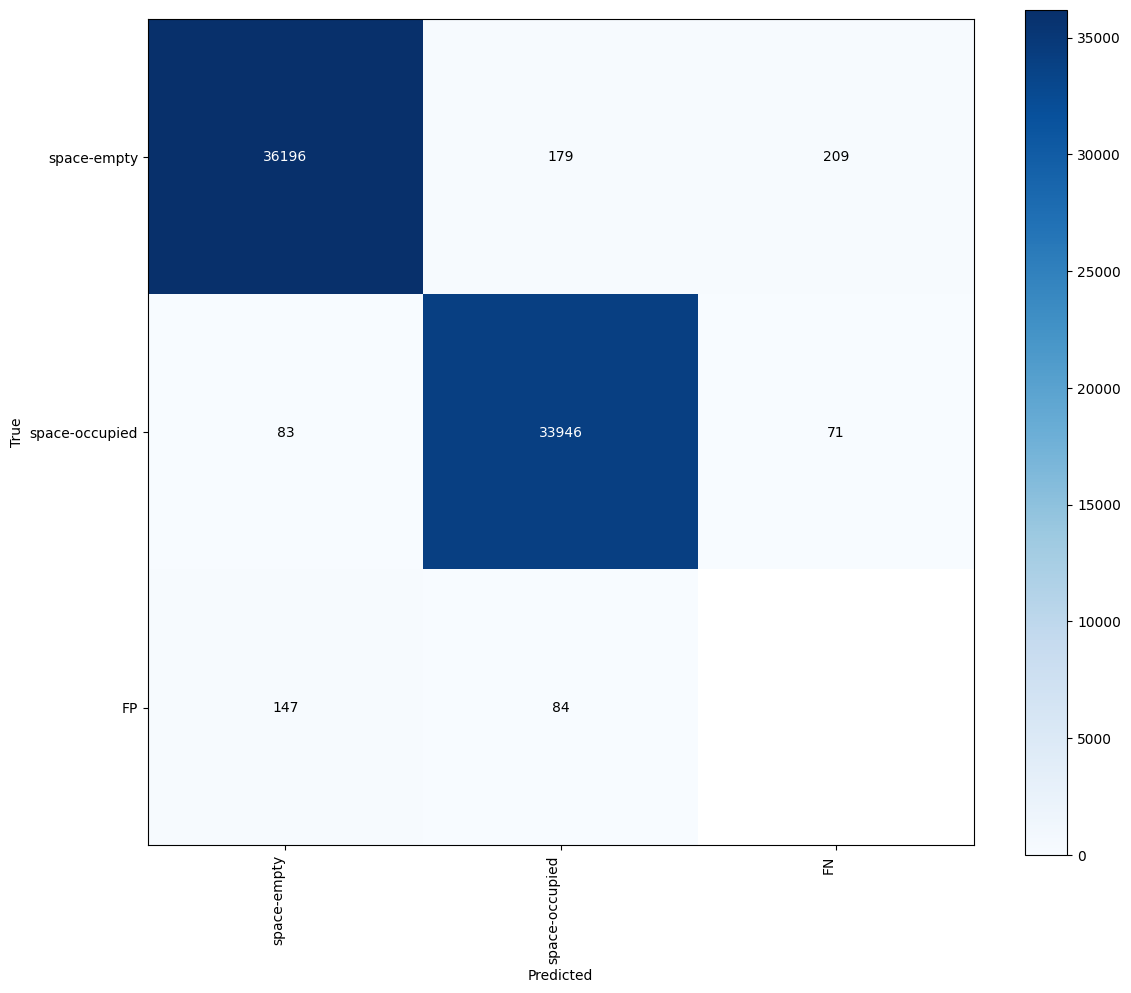

In [ ]:
from IPython.display import Image, display
import os

conf_mat_path = os.path.join(RUN_DIR, 'confusion_matrix.png')
display( Image(filename=conf_mat_path) )

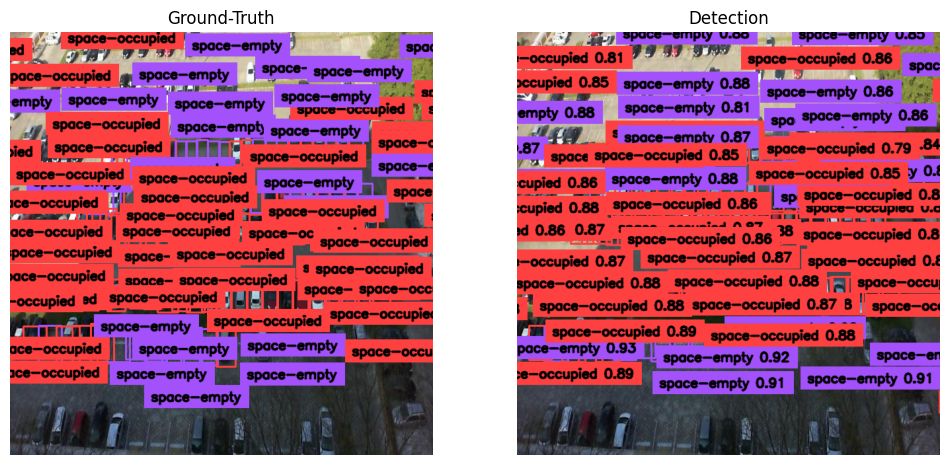

In [ ]:
path, _, ann = ds[0]
img          = Image.open(path)
dets         = eval_model.predict(img, threshold=0.5)

ts = sv.calculate_optimal_text_scale(resolution_wh=img.size)
th = sv.calculate_optimal_line_thickness(resolution_wh=img.size)
ba = sv.BoxAnnotator(thickness=th)
la = sv.LabelAnnotator(
    text_color     = sv.Color.BLACK,
    text_scale     = ts,
    text_thickness = th,
    smart_position = True
)

gt_lbls = [f"{ds.classes[c]}"        for c in ann.class_id]
dt_lbls = [f"{ds.classes[c]} {p:.2f}" for c,p in zip(dets.class_id, dets.confidence)]

gt_img = ba.annotate(img.copy(), ann)
gt_img = la.annotate(gt_img, ann, gt_lbls)
dt_img = ba.annotate(img.copy(), dets)
dt_img = la.annotate(dt_img, dets, dt_lbls)

sv.plot_images_grid(
    images    = [gt_img, dt_img],
    grid_size = (1, 2),
    titles    = ["Ground-Truth", "Detection"]
)

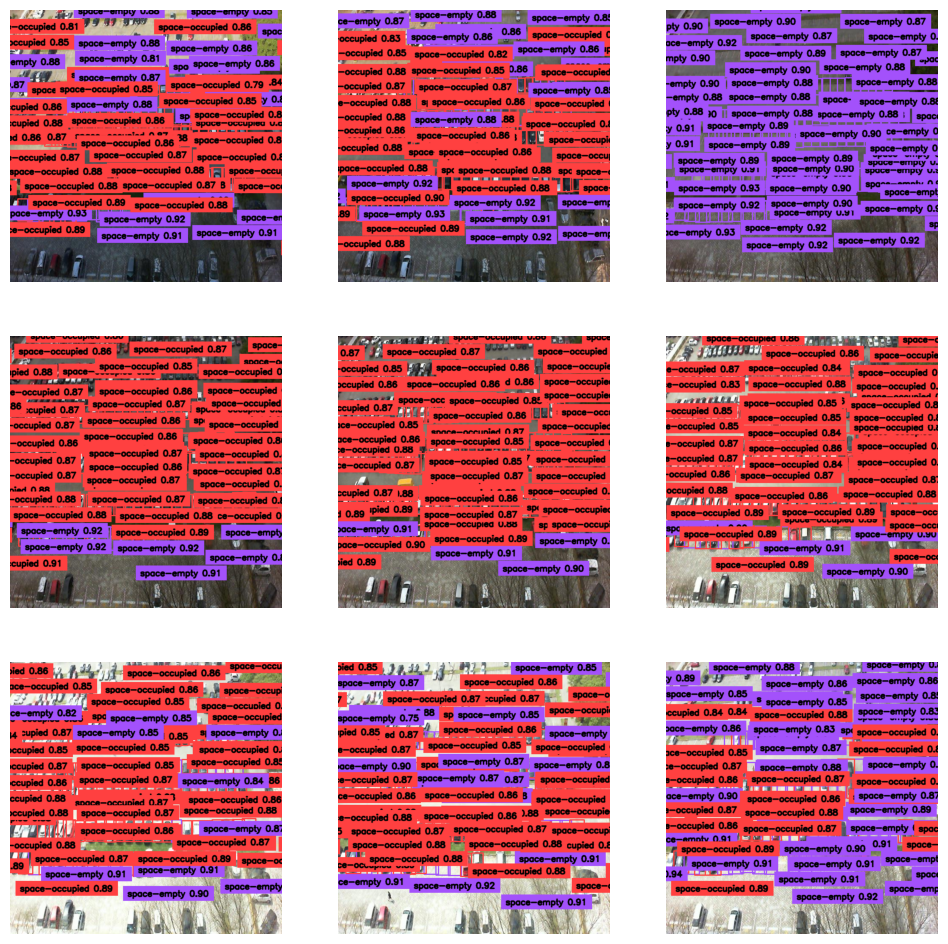

Detections grid → detections_grid.png


In [ ]:
det_images = []
for i in range(min(9, len(ds))):
    p, _, _ = ds[i]
    im      = Image.open(p)
    d       = eval_model.predict(im, threshold=0.5)
    o       = ba.annotate(im.copy(), d)
    o       = la.annotate(o, d, [f"{ds.classes[c]} {conf:.2f}"
                                 for c,conf in zip(d.class_id, d.confidence)])
    det_images.append(o)

sv.plot_images_grid(images=det_images, grid_size=(3,3), size=(12,12))
plt.gcf().savefig(os.path.join(RUN_DIR, 'detections_grid.png'), bbox_inches='tight')
plt.close()
print("Detections grid → detections_grid.png")


In [ ]:
!cp -r /content/output /content/drive/MyDrive/rfdetr_pklot_run/output

In [ ]:
import torch, os

os.makedirs(CKPT_DIR, exist_ok=True)

torch.save(model.model, os.path.join(CKPT_DIR, "model_module.pth"))
print(" model_module.pth saved →", CKPT_DIR)

 model_module.pth saved → /content/drive/MyDrive/rfdetr_pklot_run/checkpoint


## References:
RF-DETR: https://github.com/roboflow/rfdetr  
Supervision: https://github.com/roboflow/supervision  
PyYAML: https://pyyaml.org/wiki/PyYAMLDocumentation  
PyTorch: https://pytorch.org/docs/  
tqdm: https://tqdm.github.io/  
Matplotlib: https://matplotlib.org/stable/users/